# Importing libraries

In [44]:
import pandas as pd

In [45]:
import numpy as np

In [46]:
import matplotlib.pyplot as plt

In [47]:
import seaborn as sns

In [48]:
import warnings
warnings.filterwarnings('ignore')

# Loading the dataset

In [49]:
df=pd.read_csv('SCMS_Delivery_History_Dataset.csv')

In [50]:
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


In [51]:
# No. of rows and columns
df.shape

(10324, 33)

In [52]:
# List of Columns

df.columns

Index(['ID', 'Project Code', 'PQ #', 'PO / SO #', 'ASN/DN #', 'Country',
       'Managed By', 'Fulfill Via', 'Vendor INCO Term', 'Shipment Mode',
       'PQ First Sent to Client Date', 'PO Sent to Vendor Date',
       'Scheduled Delivery Date', 'Delivered to Client Date',
       'Delivery Recorded Date', 'Product Group', 'Sub Classification',
       'Vendor', 'Item Description', 'Molecule/Test Type', 'Brand', 'Dosage',
       'Dosage Form', 'Unit of Measure (Per Pack)', 'Line Item Quantity',
       'Line Item Value', 'Pack Price', 'Unit Price', 'Manufacturing Site',
       'First Line Designation', 'Weight (Kilograms)', 'Freight Cost (USD)',
       'Line Item Insurance (USD)'],
      dtype='object')

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   ID                            10324 non-null  int64  
 1   Project Code                  10324 non-null  object 
 2   PQ #                          10324 non-null  object 
 3   PO / SO #                     10324 non-null  object 
 4   ASN/DN #                      10324 non-null  object 
 5   Country                       10324 non-null  object 
 6   Managed By                    10324 non-null  object 
 7   Fulfill Via                   10324 non-null  object 
 8   Vendor INCO Term              10324 non-null  object 
 9   Shipment Mode                 9964 non-null   object 
 10  PQ First Sent to Client Date  10324 non-null  object 
 11  PO Sent to Vendor Date        10324 non-null  object 
 12  Scheduled Delivery Date       10324 non-null  object 
 13  D

# Changing data type to date for specific columns

In [54]:
# Changing data type to date

df['Scheduled Delivery Date'] = pd.to_datetime(df['Scheduled Delivery Date'], dayfirst=True)

In [55]:
# Changing data type to date

df['Delivered to Client Date'] = pd.to_datetime(df['Delivered to Client Date'], dayfirst=True)

In [56]:
# Changing data type to date

df['Delivery Recorded Date'] = pd.to_datetime(df['Delivery Recorded Date'], dayfirst=True)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            10324 non-null  int64         
 1   Project Code                  10324 non-null  object        
 2   PQ #                          10324 non-null  object        
 3   PO / SO #                     10324 non-null  object        
 4   ASN/DN #                      10324 non-null  object        
 5   Country                       10324 non-null  object        
 6   Managed By                    10324 non-null  object        
 7   Fulfill Via                   10324 non-null  object        
 8   Vendor INCO Term              10324 non-null  object        
 9   Shipment Mode                 9964 non-null   object        
 10  PQ First Sent to Client Date  10324 non-null  object        
 11  PO Sent to Vendor Date      

# Handle missing values

In [58]:
# Fetching the no. of missing values

df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [59]:
df.describe()

,ID,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Line Item Insurance (USD)
count,10324.000000,10324,10324,10324,10324.000000,10324.000000,1.032400e+04,10324.000000,10324.000000,10037.000000
mean,51098.968229,2011-10-04 15:30:28.593568512,2011-09-28 14:56:34.963192576,2011-10-01 12:33:28.523827968,77.990895,18332.534870,1.576506e+05,21.910241,0.611701,240.117626
min,1.000000,2006-05-02 00:00:00,2006-05-02 00:00:00,2006-05-02 00:00:00,1.000000,1.000000,0.000000e+00,0.000000,0.000000,0.000000
25%,12795.750000,2009-09-08 00:00:00,2009-09-01 00:00:00,2009-09-01 00:00:00,30.000000,408.000000,4.314593e+03,4.120000,0.080000,6.510000
50%,57540.500000,2011-12-05 00:00:00,2011-11-25 00:00:00,2011-11-25 00:00:00,60.000000,3000.000000,3.047147e+04,9.300000,0.160000,47.040000
75%,83648.250000,2013-12-23 00:00:00,2013-12-23 00:00:00,2014-01-13 00:00:00,90.000000,17039.750000,1.664471e+05,23.592500,0.470000,252.400000
max,86823.000000,2015-12-31 00:00:00,2015-09-14 00:00:00,2015-09-14 00:00:00,1000.000000,619999.000000,5.951990e+06,1345.640000,238.650000,7708.440000
std,31944.332496,NaN,NaN,NaN,76.579764,40035.302961,3.452921e+05,45.609223,3.275808,500.190568


In [60]:
df.describe(include = 'object')

,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,...,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD)
count,10324,10324,10324,10324,10324,10324,10324,10324,9964,10324,...,10324,10324,10324,10324,8588,10324,10324,10324,10324,10324
unique,142,1237,6233,7030,43,4,2,8,4,765,...,73,184,86,48,54,17,88,2,4688,6733
top,116-ZA-T30,Pre-PQ Process,SCMS-199289,ASN-19166,South Africa,PMO - US,From RDC,N/A - From RDC,Air,Pre-PQ Process,...,SCMS from RDC,"Efavirenz 600mg, tablets, 30 Tabs",Efavirenz,Generic,300mg,Tablet,"Aurobindo Unit III, India",Yes,Weight Captured Separately,Freight Included in Commodity Cost
freq,768,2681,67,54,1406,10265,5404,5404,6113,2476,...,5404,755,1125,7285,990,3532,3172,7030,1507,1442


In [61]:
#For Shipment Mode column

df['Shipment Mode'].mode()

0    Air
Name: Shipment Mode, dtype: object

In [62]:
df['Shipment Mode'].unique()

array(['Air', nan, 'Truck', 'Air Charter', 'Ocean'], dtype=object)

In [63]:
# Filling missing values with mode

df['Shipment Mode'].fillna(df['Shipment Mode'].mode()[0], inplace=True)

In [64]:
# Fetching the no. of missing values

df.isnull().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                      0
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [65]:
# For Dosage column----> it is of object type

df['Dosage'].nunique()

54

In [66]:
df['Dosage'].mode()

0    300mg
Name: Dosage, dtype: object

In [67]:
# If we have 54 unique dosages, filling 1700 missing values with one value will create a huge spike at 300mg

In [68]:
df['Dosage'] = df['Dosage'].fillna('Unknown')

In [69]:
# Fetching the no. of missing values

df.isnull().sum()

ID                                0
Project Code                      0
PQ #                              0
PO / SO #                         0
ASN/DN #                          0
Country                           0
Managed By                        0
Fulfill Via                       0
Vendor INCO Term                  0
Shipment Mode                     0
PQ First Sent to Client Date      0
PO Sent to Vendor Date            0
Scheduled Delivery Date           0
Delivered to Client Date          0
Delivery Recorded Date            0
Product Group                     0
Sub Classification                0
Vendor                            0
Item Description                  0
Molecule/Test Type                0
Brand                             0
Dosage                            0
Dosage Form                       0
Unit of Measure (Per Pack)        0
Line Item Quantity                0
Line Item Value                   0
Pack Price                        0
Unit Price                  

In [70]:
# for Line Item Insurance (USD) column-----> it is numeric type

df['Line Item Insurance (USD)'].nunique()

6722

In [71]:
# filling missing value with median because column is numeric type

df['Line Item Insurance (USD)'] = df['Line Item Insurance (USD)'].fillna(df['Line Item Insurance (USD)'].median())

In [72]:
# Fetching the no. of missing values

df.isnull().sum()

ID                              0
Project Code                    0
PQ #                            0
PO / SO #                       0
ASN/DN #                        0
Country                         0
Managed By                      0
Fulfill Via                     0
Vendor INCO Term                0
Shipment Mode                   0
PQ First Sent to Client Date    0
PO Sent to Vendor Date          0
Scheduled Delivery Date         0
Delivered to Client Date        0
Delivery Recorded Date          0
Product Group                   0
Sub Classification              0
Vendor                          0
Item Description                0
Molecule/Test Type              0
Brand                           0
Dosage                          0
Dosage Form                     0
Unit of Measure (Per Pack)      0
Line Item Quantity              0
Line Item Value                 0
Pack Price                      0
Unit Price                      0
Manufacturing Site              0
First Line Des

In [73]:
df

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,...,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,47.04
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,47.04
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,47.04
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,47.04
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,47.04
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,1392,Freight Included in Commodity Cost,134.03


# Distribution of Shipment Modes in the Dataset

In [74]:
a=df['Shipment Mode'].value_counts(normalize=True)*100
a

Shipment Mode
Air            62.698566
Truck          27.411856
Air Charter     6.296009
Ocean           3.593568
Name: proportion, dtype: float64

Text(0, 0.5, 'Count')

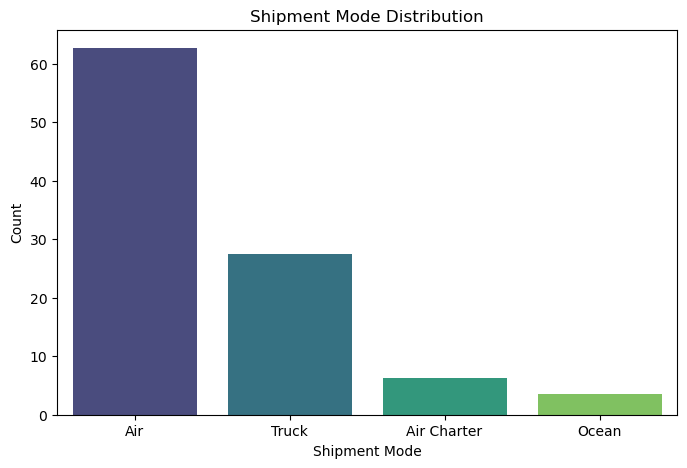

In [75]:
# Plotting bar chart

plt.figure(figsize=(8,5))

sns.barplot(x=a.index, y=a.values, palette='viridis')

plt.title('Shipment Mode Distribution')

plt.xlabel('Shipment Mode')

plt.ylabel('Count')

# Top 5 Countries by Orders

In [76]:
b=(df['Country'].value_counts(normalize=True)*100).head(5)
b

Country
South Africa     13.618752
Nigeria          11.565285
Côte d'Ivoire    10.490120
Uganda            7.545525
Vietnam           6.664084
Name: proportion, dtype: float64

<Axes: xlabel='Country'>

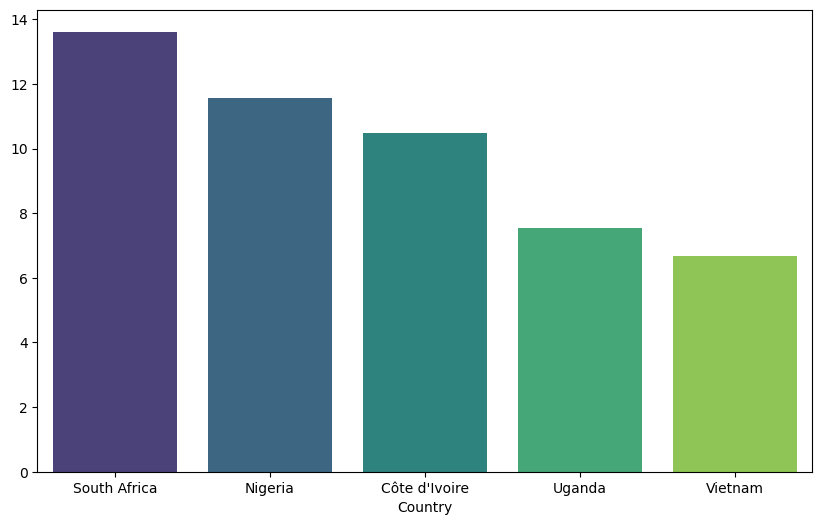

In [77]:
# Ploting Bar Chart

plt.figure(figsize=(10,6))

sns.barplot(x=b.index,y=b.values, palette='viridis')

## Top 5 Vendor Analysis

In [79]:
# Top 5 vendors

c=df['Vendor'].value_counts().head()
c

Vendor
SCMS from RDC               5404
Orgenics, Ltd                754
S. BUYS WHOLESALER           715
Aurobindo Pharma Limited     668
Trinity Biotech, Plc         356
Name: count, dtype: int64

Text(0, 0.5, 'Count')

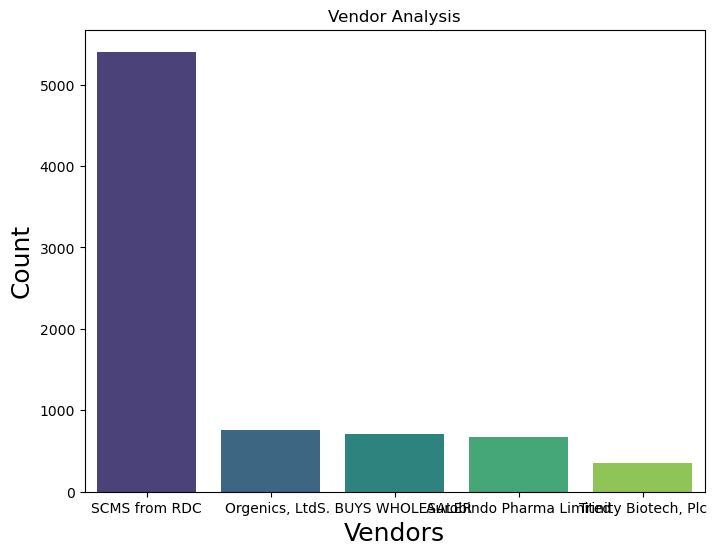

In [81]:
# Plotting bar chart

plt.figure(figsize=(8,6))

sns.barplot(x=c.index,y=c.values, palette='viridis')

plt.title('Vendor Analysis')

plt.xlabel('Vendors',size=18)

plt.ylabel('Count',size=18)

# Late vs On-time deliveries

In [84]:
# On-time delivery rate

on_time_rate = (
    (df['Delivered to Client Date'] <= df['Scheduled Delivery Date']).mean()
) * 100
on_time_rate

np.float64(88.51220457187137)

In [85]:
# delay delivery rate

late_rate = (
    (df['Delivered to Client Date'] > df['Scheduled Delivery Date']).mean()
) * 100

late_rate

np.float64(11.487795428128631)

## Vendor-wise On-Time & Late Rates

In [89]:
vendor_perf = df.groupby('Vendor').apply(
    lambda x: pd.Series({
        'On-Time_delivery_rate': (x['Delivered to Client Date'] <= x['Scheduled Delivery Date']).mean() * 100,
        'Late_delivery_rate': (x['Delivered to Client Date'] > x['Scheduled Delivery Date']).mean() * 100
    })
)
vendor_perf

,On-Time_delivery_rate,Late_delivery_rate
Vendor,,
ABBOTT LABORATORIES (PUERTO RICO),100.000000,0.000000
ABBOTT LOGISTICS B.V.,100.000000,0.000000
ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),98.847262,1.152738
"ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTERNATIONAL CO.)",100.000000,0.000000
"ACCESS BIO, INC.",100.000000,0.000000
...,...,...
THE MEDICAL EXPORT GROUP BV,100.000000,0.000000
TURE PHARMACEUTICALS & MEDICAL SUPPLIES P.L.C.,100.000000,0.000000
"Trinity Biotech, Plc",99.719101,0.280899


## Region-wise On-Time & Late Rates

In [90]:
region_perf = df.groupby('Country').apply(
    lambda x: pd.Series({
        'On-Time_delivery_rate': (x['Delivered to Client Date'] <= x['Scheduled Delivery Date']).mean() * 100,
        'Late_delivery_rate': (x['Delivered to Client Date'] > x['Scheduled Delivery Date']).mean() * 100
    })
)
region_perf

,On-Time_delivery_rate,Late_delivery_rate
Country,,
Afghanistan,100.000000,0.000000
Angola,100.000000,0.000000
Belize,100.000000,0.000000
Benin,76.923077,23.076923
Botswana,97.142857,2.857143
Burkina Faso,100.000000,0.000000
Burundi,61.224490,38.775510
Cameroon,90.666667,9.333333
"Congo, DRC",75.075075,24.924925


## Shipment mode wise On-Time & Late Rates

In [106]:
SM_perf = df.groupby('Shipment Mode').apply(
    lambda x: pd.Series({
        'On-Time_delivery_rate': (x['Delivered to Client Date'] <= x['Scheduled Delivery Date']).mean() * 100,
        'Late_delivery_rate': (x['Delivered to Client Date'] > x['Scheduled Delivery Date']).mean() * 100
    })
)
SM_perf

,On-Time_delivery_rate,Late_delivery_rate
Shipment Mode,,
Air,90.869767,9.130233
Air Charter,88.461538,11.538462
Ocean,82.479784,17.520216
Truck,83.922261,16.077739


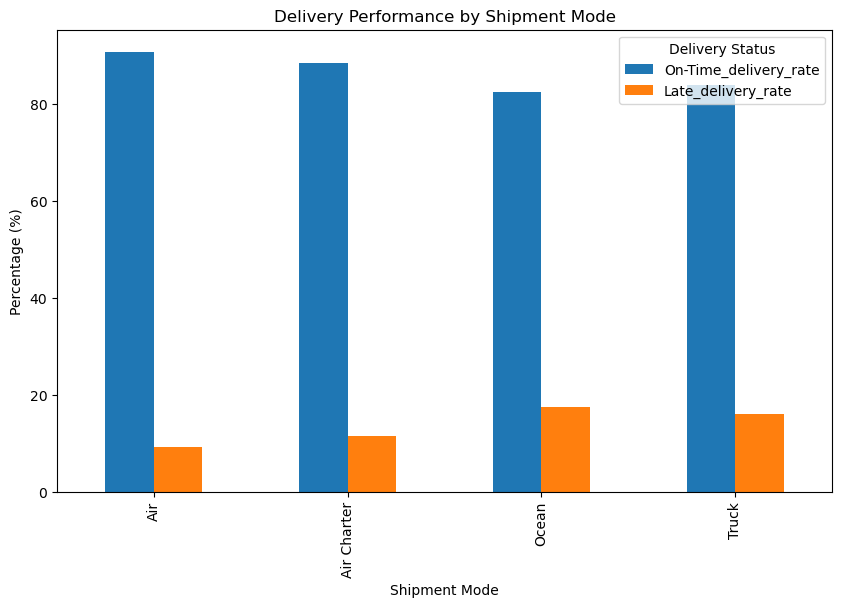

In [110]:

# Plot grouped bar chart

SM_perf.plot(kind='bar', figsize=(10,6))
plt.title('Delivery Performance by Shipment Mode')
plt.ylabel('Percentage (%)')
plt.xlabel('Shipment Mode')
plt.legend(title='Delivery Status')
plt.show()

# Cost Analysis

In [92]:
# Higher weight shipments tend to have higher freight cost.

In [93]:
# convert a column into numeric

df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')

In [95]:
# Shipment mode wise 

d=df.groupby('Shipment Mode')['Weight (Kilograms)'].sum()
d

Shipment Mode
Air            8691995.0
Air Charter    3420128.0
Ocean          1939423.0
Truck          7768994.0
Name: Weight (Kilograms), dtype: float64

## Cross-Tabulation

In [113]:
pd.crosstab(df['Shipment Mode'] , df['Vendor'])

Vendor,ABBOTT LABORATORIES (PUERTO RICO),ABBOTT LOGISTICS B.V.,ABBVIE LOGISTICS (FORMERLY ABBOTT LOGISTICS BV),"ABBVIE, SRL (FORMALLY ABBOTT LABORATORIES INTERNATIONAL CO.)","ACCESS BIO, INC.",ACCOUN NIGERIA LIMITED,ACOUNS NIGERIA LTD,ACTION MEDEOR E.V.,AHN (PTY) LTD (AKA UCB (S.A.),AMSTELFARMA B.V.,...,SUB-SAHARAN BIOMEDICAL P.L.C.,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LABORATORIES LIMITED),SWORDS LABORATORIES,SYSMEX AMERICA INC,"Standard Diagnostics, Inc.",THE MEDICAL EXPORT GROUP BV,TURE PHARMACEUTICALS & MEDICAL SUPPLIES P.L.C.,"Trinity Biotech, Plc",WAGENIA,ZEPHYR BIOMEDICALS
Shipment Mode,,,,,,,,,,,,,,,,,,,,,
Air,1,1,342,1,1,3,1,1,0,7,...,1,9,3,1,98,1,2,353,0,5
Air Charter,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Ocean,0,0,5,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,3,0,0
Truck,0,0,0,3,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,2,0


# Correlation between Line Item Quantity & Line Item Value

In [118]:

#Hypothesis: Larger quantities should have higher total value.

corr_qty_value = df['Line Item Quantity'].corr(df['Line Item Value'])
print("Correlation - ", corr_qty_value)

Correlation -  0.8390814425828664


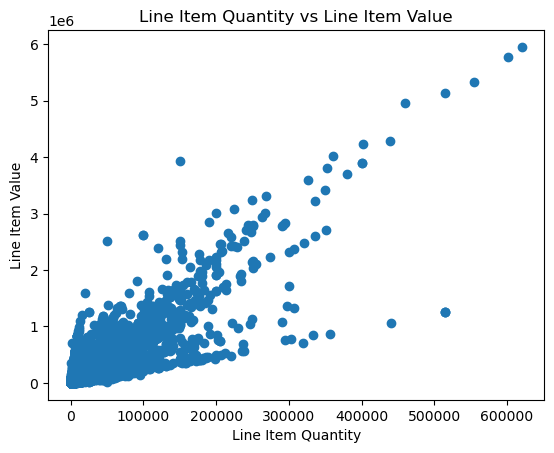

In [117]:
plt.scatter(df['Line Item Quantity'], df['Line Item Value'])
plt.xlabel('Line Item Quantity')
plt.ylabel('Line Item Value')
plt.title('Line Item Quantity vs Line Item Value')
plt.show()

# Correlation between Freight Cost & Weight

In [119]:

# Make sure Weight and Freight Cost are numeric
df['Weight (Kilograms)'] = pd.to_numeric(df['Weight (Kilograms)'], errors='coerce')
df['Freight Cost (USD)'] = pd.to_numeric(df['Freight Cost (USD)'], errors='coerce')

corr_fw = df['Freight Cost (USD)'].corr(df['Weight (Kilograms)'])
print("Correlation - ", corr_fw)

Correlation -  0.23205230487188785


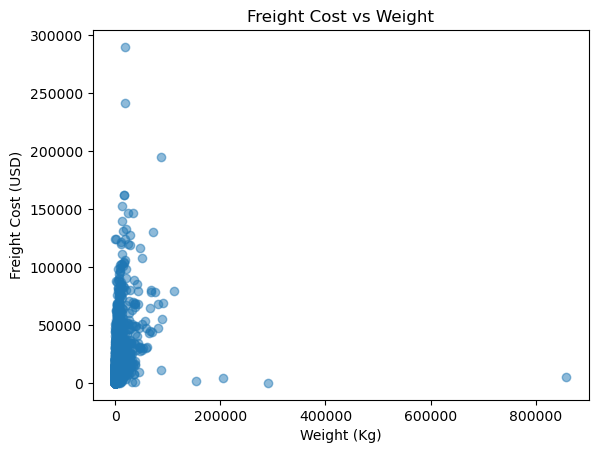

In [124]:
plt.scatter(df['Weight (Kilograms)'], df['Freight Cost (USD)'], alpha=0.5)
plt.xlabel('Weight (Kg)')
plt.ylabel('Freight Cost (USD)')
plt.title('Freight Cost vs Weight')
plt.show()